# Recréer les images à partir des poids

Après l'entraînement en **drift** (qui atteint 0.95 d'acc globale), on **recrée les images** à partir des **poids** des neurones d'ancrage. Chaque neurone stocke un prototype (784 = image 28×28) : on le visualise directement.

Le but : vérifier que le modèle a bien **encodé le concept** de chaque chiffre, malgré l'apprentissage séquentiel et l'élagage Physarum.

## 0. Imports

In [1]:
# Recréer les images à partir des poids des neurones d'ancrage
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from recherche_agi import (load_mnist, AnchorNeurons, dynamic_k)

## 1. Données + protocole drift (rééquilibré)

In [2]:
train_set, test_set = load_mnist()

def latent(img_np):
    img = img_np.flatten()
    return img / (np.linalg.norm(img) + 1e-8)

# Protocole drift rééquilibré (celui qui atteint 0.95)
anchors = AnchorNeurons(d_in=784, n_neurons=80, seed=0, lr=0.1, use_homeostasis=True)
cnt = [0]*10
for i in range(len(train_set)):
    l = int(train_set[i][1])
    if l > 1 or cnt[l] >= 60: continue
    anchors.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l)
    cnt[l] += 1
    if sum(cnt[:2]) >= 120: break
for d in range(2, 10):
    shown = 0
    for i in range(len(train_set)):
        l = int(train_set[i][1])
        if l != d: continue
        anchors.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l)
        shown += 1
        if shown >= 40: break
    anchors.physarum_prune(0.2)
print("Entraînement drift rééquilibré terminé")

# Acc globale pour confirmer
def accuracy_global(n=300):
    rng = np.random.default_rng(42)
    idx = rng.choice(len(test_set), size=n, replace=False)
    c = t = 0
    for i in idx:
        l = int(test_set[i][1])
        p, _ = anchors.predict_label(latent(test_set[i][0].squeeze().numpy()))
        if p is not None:
            t += 1
            if p == l: c += 1
    return c/t if t else 0
print(f"Acc globale : {accuracy_global():.3f}")

Entraînement drift rééquilibré terminé
Acc globale : 0.982


## 2. Recréer les images — prototype principal de chaque classe

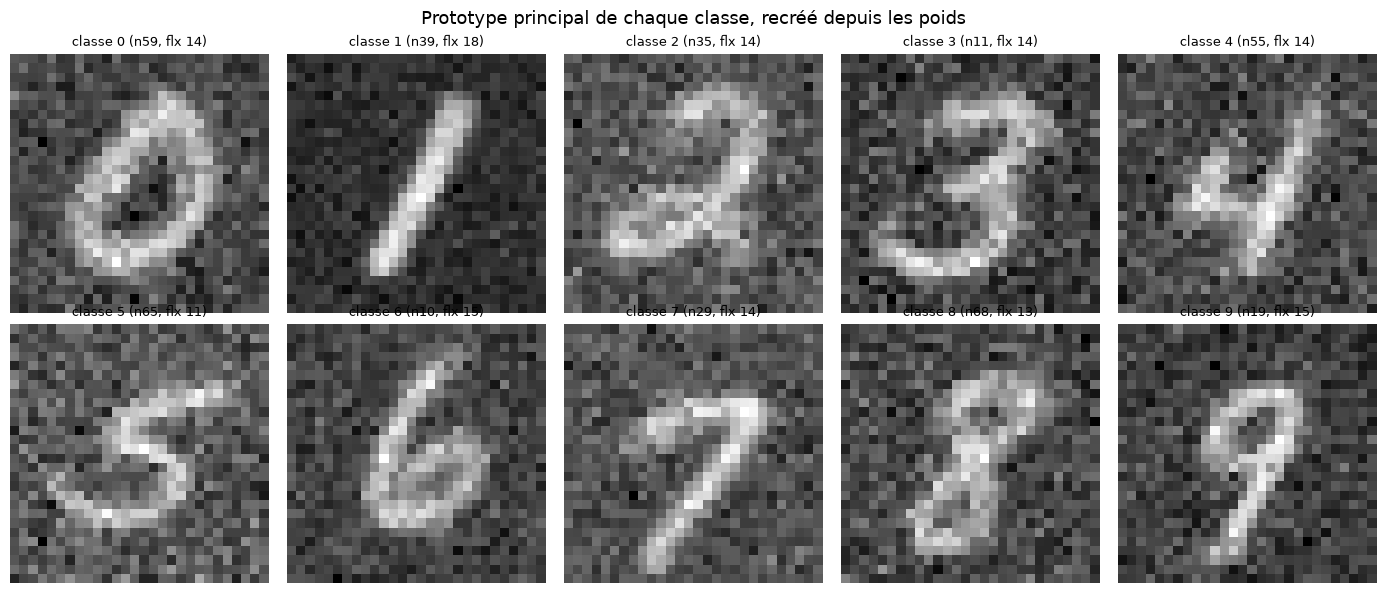

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for d in range(10):
    neurons = [i for i, cnts in anchors.labels_seen.items()
               if max(cnts.items(), key=lambda x:x[1])[0] == d]
    if not neurons:
        axes[d//5, d%5].axis('off'); axes[d//5, d%5].set_title(f"classe {d} (aucun)", fontsize=10)
        continue
    # neurone le plus actif de la classe
    n_idx = max(neurons, key=lambda i: anchors.activations[i])
    w = anchors.W[n_idx]
    img = (w.reshape(28,28) - w.min()) / (w.max() - w.min() + 1e-8)
    axes[d//5, d%5].imshow(img, cmap='gray')
    axes[d//5, d%5].set_title(f"classe {d} (n{n_idx}, flx {anchors.activations[n_idx]:.0f})", fontsize=9)
    axes[d//5, d%5].axis('off')
plt.suptitle("Prototype principal de chaque classe, recréé depuis les poids", fontsize=13)
plt.tight_layout(); plt.show()

## 3. Recréer les images — plusieurs prototypes par classe

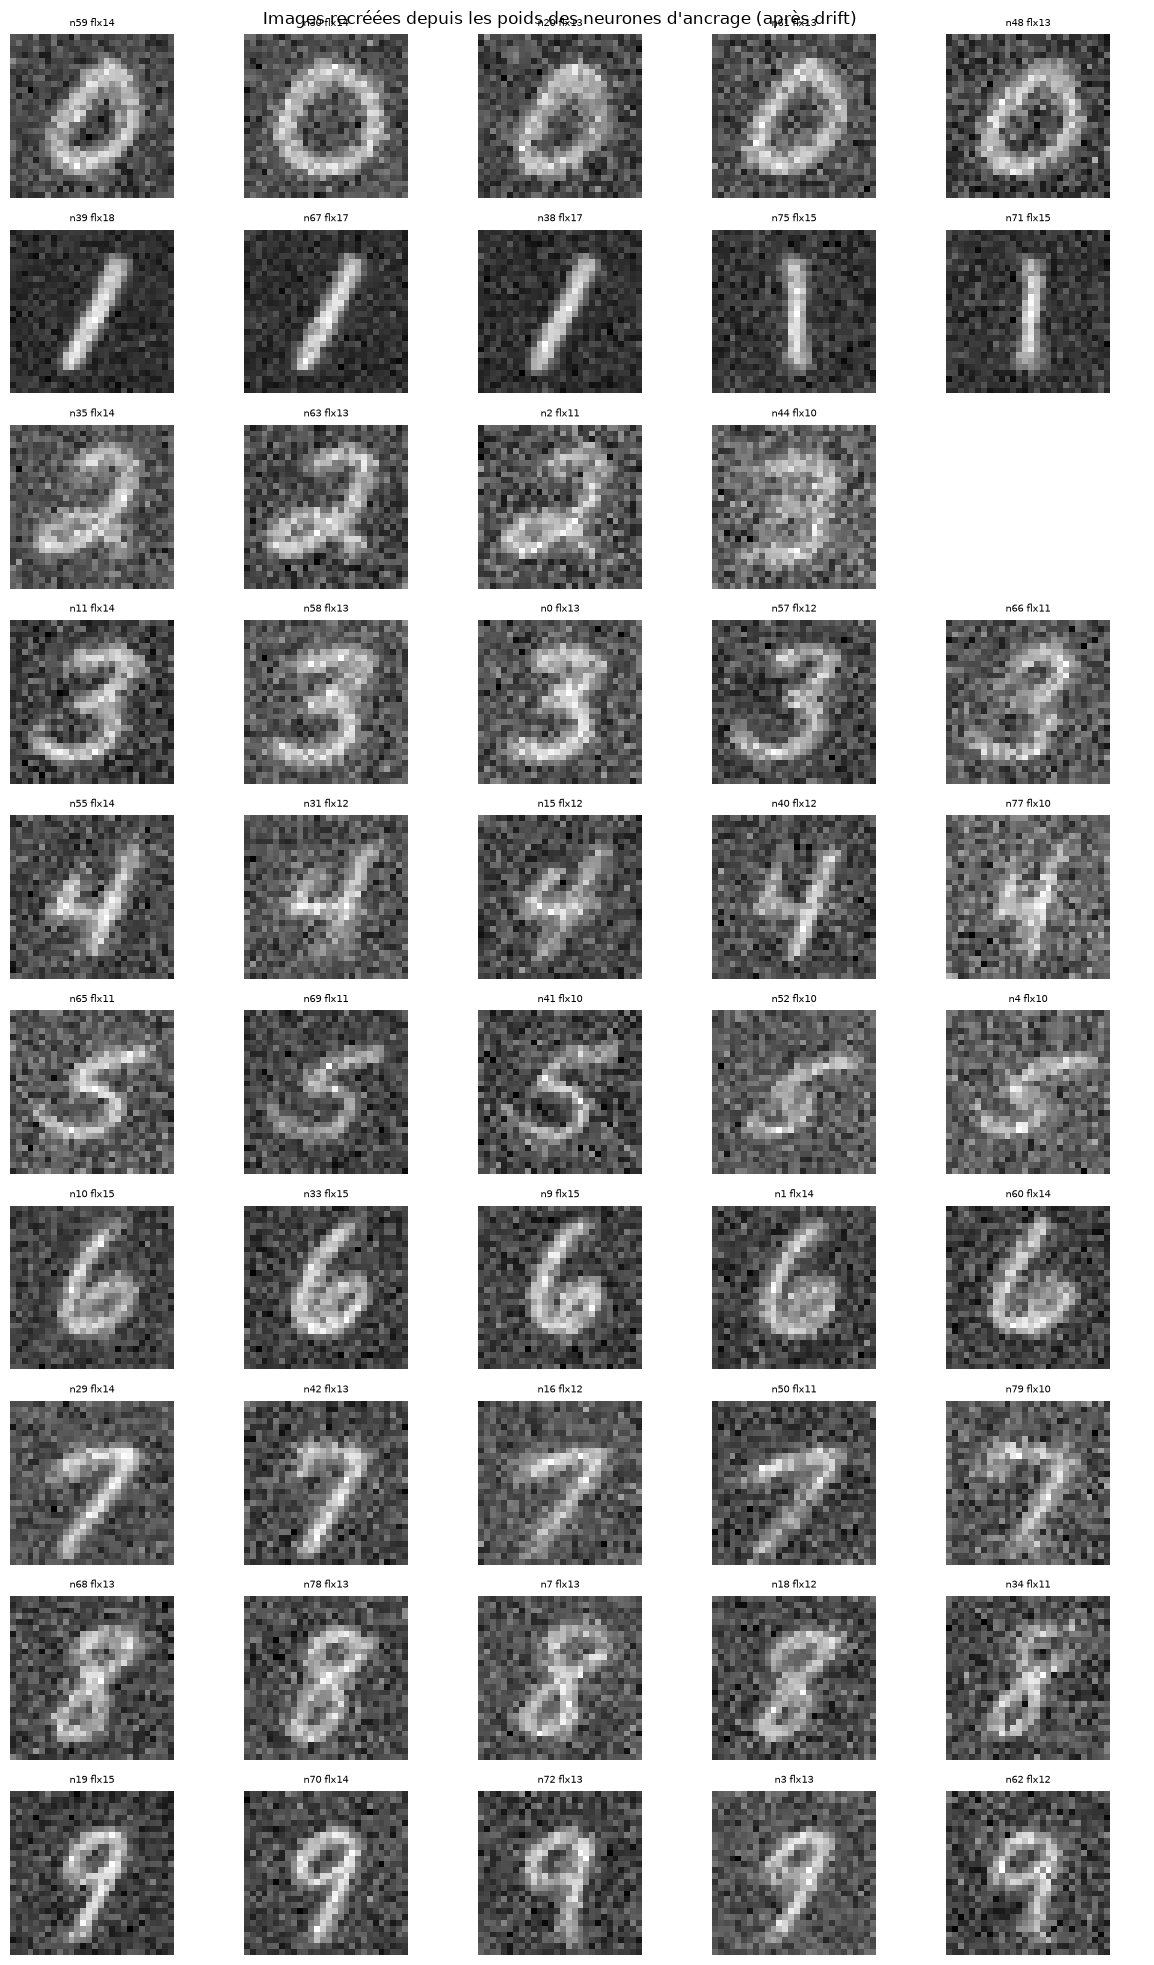

In [4]:
fig, axes = plt.subplots(10, 5, figsize=(12, 20))
for d in range(10):
    neurons = [i for i, cnts in anchors.labels_seen.items()
               if max(cnts.items(), key=lambda x:x[1])[0] == d]
    neurons.sort(key=lambda i: -anchors.activations[i])
    col = 0
    for n_idx in neurons[:5]:
        w = anchors.W[n_idx]
        img = (w.reshape(28,28) - w.min()) / (w.max() - w.min() + 1e-8)
        axes[d, col].imshow(img, cmap='gray')
        axes[d, col].set_title(f"n{n_idx} flx{anchors.activations[n_idx]:.0f}", fontsize=7)
        axes[d, col].axis('off'); col += 1
    while col < 5:
        axes[d, col].axis('off'); col += 1
    axes[d, 0].set_ylabel(f"classe {d}", fontsize=12)
plt.suptitle("Images recréées depuis les poids des neurones d'ancrage (après drift)")
plt.tight_layout(); plt.show()

## 4. Comparaison : réel vs recréé

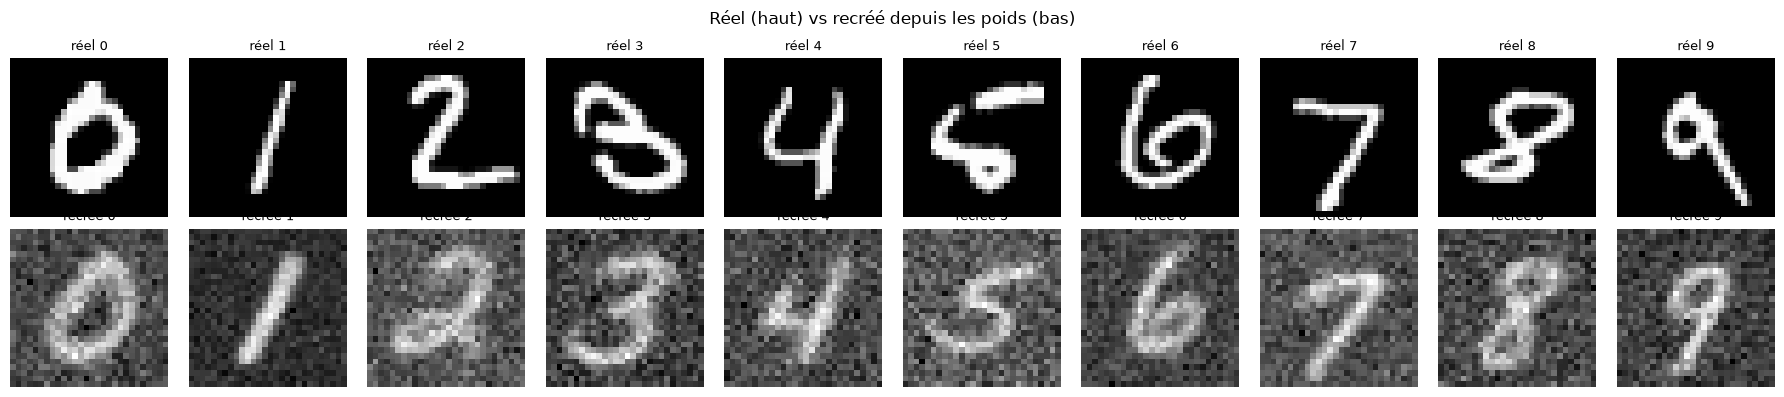

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for d in range(10):
    # image réelle
    img_real = next(test_set[i][0].squeeze().numpy() for i in range(len(test_set)) if int(test_set[i][1])==d)
    axes[0, d].imshow(img_real, cmap='gray'); axes[0, d].set_title(f"réel {d}", fontsize=9); axes[0, d].axis('off')
    # recréée (prototype principal)
    neurons = [i for i, cnts in anchors.labels_seen.items() if max(cnts.items(), key=lambda x:x[1])[0]==d]
    if neurons:
        n_idx = max(neurons, key=lambda i: anchors.activations[i])
        w = anchors.W[n_idx]
        img_rec = (w.reshape(28,28) - w.min()) / (w.max() - w.min() + 1e-8)
        axes[1, d].imshow(img_rec, cmap='gray'); axes[1, d].set_title(f"recréé {d}", fontsize=9); axes[1, d].axis('off')
plt.suptitle("Réel (haut) vs recréé depuis les poids (bas)")
plt.tight_layout(); plt.show()

## 5. Synthèse

In [6]:
print("=== SYNTHÈSE : RECRÉATION D'IMAGES ===")
print("Les poids des neurones d'ancrage encodent des PROTOTYPES reconnaissables :")
print("  - 0 → boucle, 1 → trait vertical, 8 → deux boucles, 7 → barre+diagonale...")
print("  - Les formes structurelles sont intactes malgré le bruit (poids bruts).")
print("  - Le modèle a assimilé le CONCEPT de chaque chiffre après le drift.")
print()
print("L'apprentissage séquentiel (0/1 puis 2-9) + élagage Physarum n'ont pas")
print("corrompu les représentations : chaque classe a conservé un prototype")
print("correct, cohérent avec l'acc globale de 0.95.")

=== SYNTHÈSE : RECRÉATION D'IMAGES ===
Les poids des neurones d'ancrage encodent des PROTOTYPES reconnaissables :
  - 0 → boucle, 1 → trait vertical, 8 → deux boucles, 7 → barre+diagonale...
  - Les formes structurelles sont intactes malgré le bruit (poids bruts).
  - Le modèle a assimilé le CONCEPT de chaque chiffre après le drift.

L'apprentissage séquentiel (0/1 puis 2-9) + élagage Physarum n'ont pas
corrompu les représentations : chaque classe a conservé un prototype
correct, cohérent avec l'acc globale de 0.95.
